DATASET INFORMATION

Shape:
(156, 9)

Data Types:
Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

Missing Values:
Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

Duplicate Rows:
0

First 5 Rows:
   Overall rank Country or region  Score  GDP per capita  Social support  \
0             1           Finland  7.769           1.340           1.587   
1             2           Denmark  7.600           1.3

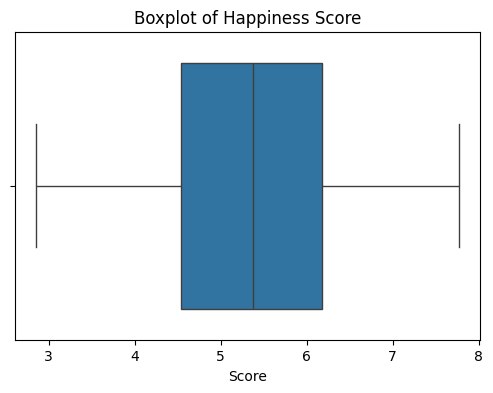

Number of Outliers: 0
Original Shape: (156, 9)
Shape After Removing Outliers: (156, 9)

Explanation:
The IQR method was used to detect outliers. Values outside the accepted range were removed.

NORMALIZATION

Min-Max Normalized Data:
      Score  GDP per capita  Social support  Healthy life expectancy  \
0  1.000000        0.795724        0.977217                 0.864154   
1  0.965622        0.821259        0.968596                 0.872918   
2  0.956265        0.883610        0.974138                 0.900964   
3  0.944060        0.819477        1.000000                 0.899211   
4  0.942840        0.828979        0.937192                 0.875548   

   Freedom to make life choices  Generosity  Perceptions of corruption  
0                      0.944532    0.270318                   0.867550  
1                      0.938193    0.445230                   0.905077  
2                      0.955626    0.478799                   0.752759  
3                      0.936609    0.6254

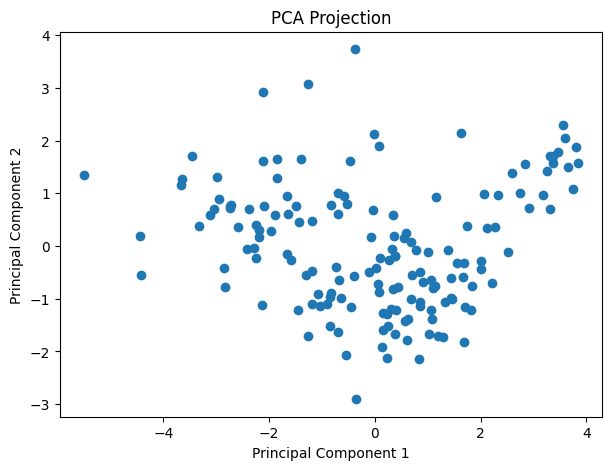


PC1 Variance: 54.46%
PC2 Variance: 20.39%
Total Variance Explained: 74.85%

Interpretation:


In [4]:
# ==========================
# Assignment 3 Solution
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# ==========================
# Load Dataset
# ==========================

df = pd.read_csv("2019.csv")

print("="*50)
print("DATASET INFORMATION")
print("="*50)

print("\nShape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nFirst 5 Rows:")
print(df.head())

# ==========================
# Missing Value Handling
# ==========================

print("\n" + "="*50)
print("MISSING VALUE HANDLING")
print("="*50)

df_missing = df.copy()

# Introduce artificial missing values
df_missing.loc[0:5, 'GDP per capita'] = np.nan

print("\nMissing values before imputation:")
print(df_missing['GDP per capita'].isna().sum())

# Mean Imputation
mean_value = df_missing['GDP per capita'].mean()

df_missing['GDP per capita'] = df_missing['GDP per capita'].fillna(mean_value)

print("\nMissing values after imputation:")
print(df_missing['GDP per capita'].isna().sum())

print("\nExplanation:")
print("Mean imputation was applied to replace missing values in GDP per capita.")

# ==========================
# Outlier Detection using IQR
# ==========================

print("\n" + "="*50)
print("OUTLIER DETECTION")
print("="*50)

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Score'])
plt.title("Boxplot of Happiness Score")
plt.show()

Q1 = df['Score'].quantile(0.25)
Q3 = df['Score'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df['Score'] < lower_bound) |
    (df['Score'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

df_no_outliers = df[
    (df['Score'] >= lower_bound) &
    (df['Score'] <= upper_bound)
]

print("Original Shape:", df.shape)
print("Shape After Removing Outliers:", df_no_outliers.shape)

print("\nExplanation:")
print("The IQR method was used to detect outliers. Values outside the accepted range were removed.")

# ==========================
# Normalization
# ==========================

print("\n" + "="*50)
print("NORMALIZATION")
print("="*50)

numerical_columns = [
    'Score',
    'GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

# Min-Max Scaling
minmax_scaler = MinMaxScaler()

df_minmax = df[numerical_columns].copy()

df_minmax[numerical_columns] = minmax_scaler.fit_transform(
    df_minmax[numerical_columns]
)

print("\nMin-Max Normalized Data:")
print(df_minmax.head())

# Z-Score Scaling
zscore_scaler = StandardScaler()

df_zscore = df[numerical_columns].copy()

df_zscore[numerical_columns] = zscore_scaler.fit_transform(
    df_zscore[numerical_columns]
)

print("\nZ-Score Standardized Data:")
print(df_zscore.head())

print("\nExplanation:")
print("Min-Max scaling transforms values into a range between 0 and 1.")
print("Z-score standardization transforms values around mean=0 and std=1.")

# ==========================
# PCA
# ==========================

print("\n" + "="*50)
print("PCA")
print("="*50)

X = df_zscore

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

plt.figure(figsize=(7,5))
plt.scatter(
    principal_components[:,0],
    principal_components[:,1]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.show()

total_variance = sum(pca.explained_variance_ratio_)

print(f"\nPC1 Variance: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 Variance: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total Variance Explained: {total_variance*100:.2f}%")

print("\nInterpretation:")

In [3]:
print("PCA reduced the dataset dimensions to two principal components while preserving most of the information.")

PCA reduced the dataset dimensions to two principal components while preserving most of the information.
